In [12]:
import pandas as pd

In [13]:
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/gemini_my_outputs_slake/merged.csv'

In [14]:
df = pd.read_csv(path)

In [15]:
df

,question_id,predictive_entropy,lexical_similarity,semantic_entropy,num_clusters,responses,resp_log_probs,question,accuracy,grounding_biomedclip,grounding_biomedclip_processed
0,0,0.0,0.0,0.0,0,"['MRI', 'The modality used to take this image ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What modality is used to take this image?,1.00,NaN,NaN
1,2,0.0,0.0,0.0,0,"['T2-weighted', 'T2-weighted', 'The MR weighti...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the mr weighting in this image?,1.00,"[29.957616806030273, 29.957616806030273, 34.88...","[29.957616806030273, 29.957616806030273, 34.88..."
2,7,0.0,0.0,0.0,0,"['CT', 'CT', 'CT', 'CT', 'CT', 'CT scan.', 'CT...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What modality is used to take this image?,1.00,"[30.888124465942383, 30.888124465942383, 30.88...","[30.888124465942383, 30.888124465942383, 30.88..."
3,9,0.0,0.0,0.0,0,['The main organ in the image is Lung and Hear...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the main organ in the image?,0.00,"[29.666959762573242, 28.063705444335938, 26.29...","[29.666959762573242, 28.063705444335938, 26.29..."
4,10,0.0,0.0,0.0,0,['The largest organ in the picture is the hear...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the largest organ in the picture?,0.15,"[25.58106231689453, 29.293603897094727, 29.293...","[25.58106231689453, 29.293603897094727, 29.293..."
...,...,...,...,...,...,...,...,...,...,...,...
1635,4904,0.0,0.0,0.0,0,"['The main organ in the image is Lung.', 'The ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the main organ in the image?,0.20,"[29.85805892944336, 30.292469024658203, 29.858...","[29.85805892944336, 30.292469024658203, 29.858..."
1636,4905,0.0,0.0,0.0,0,['The largest organ in the picture is the hear...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the largest organ in the picture?,0.10,"[21.569061279296875, 21.569061279296875, 21.56...","[21.569061279296875, 21.569061279296875, 21.56..."
1637,4909,0.0,0.0,0.0,0,['The diseases included in the picture are Int...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What diseases are included in the picture?,0.00,"[29.121015548706055, 20.141740798950195, 33.04...","[29.121015548706055, 20.141740798950195, 33.04..."
1638,4912,0.0,0.0,0.0,0,"['CT', 'CT', 'The modality used to take this i...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What modality is used to take this image?,1.00,"[29.060340881347656, 29.060340881347656, 18.87...","[29.060340881347656, 29.060340881347656, 18.87..."


In [16]:
df.columns

Index(['question_id', 'predictive_entropy', 'lexical_similarity',
       'semantic_entropy', 'num_clusters', 'responses', 'resp_log_probs',
       'question', 'accuracy', 'grounding_biomedclip',
       'grounding_biomedclip_processed'],
      dtype='object')

In [17]:
df.loc[1, 'grounding_biomedclip_processed']

'[29.957616806030273, 29.957616806030273, 34.884254455566406, 31.094379425048828, 30.194786071777344, 16.20429039001465, 31.094379425048828, 16.20429039001465, 30.03360366821289, 16.20429039001465, 30.03360366821289, 30.194786071777344, 16.20429039001465, 29.957616806030273, 31.094379425048828, 16.20429039001465, 29.957616806030273, 16.20429039001465, 29.957616806030273, 27.713367462158203]'

count    1639.000000
mean        0.259096
std         0.055992
min         0.035868
25%         0.222854
50%         0.263517
75%         0.298998
max         0.430970
Name: grounding_biomedclip_mean_min_max_scaled, dtype: float64


/tmp/ipykernel_1333913/3667690092.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grounding_biomedclip_mean_min_max_scaled'] = df.apply(process_grounding_biomedclip, axis=1)


<Axes: >

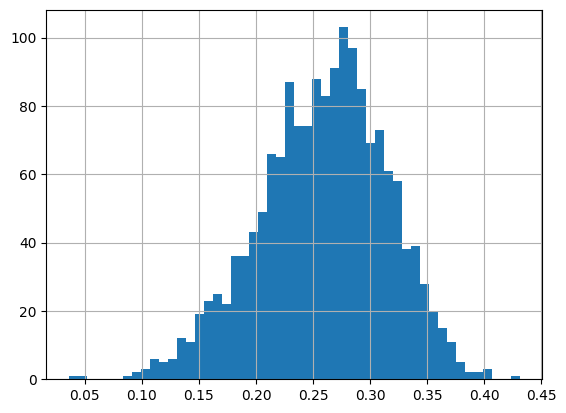

In [19]:
import ast 

tst = df.loc[1, 'grounding_biomedclip_processed']
tst = ast.literal_eval(tst)
max(tst)

import ast
import pandas as pd

# Function to safely parse and process the grounding list
def process_grounding_biomedclip(row):
    try:
        grounding_biomedclip = ast.literal_eval(row['grounding_biomedclip_processed'])
        grounding_biomedclip = [x / 100 for x in grounding_biomedclip]  # Min-max scaling with max=100
        return sum(grounding_biomedclip) / len(grounding_biomedclip) if grounding_biomedclip else 0
    except (ValueError, SyntaxError, TypeError):
        return None  # Return None to drop later

# Drop rows with missing or invalid data first
df = df.dropna(subset=['grounding_biomedclip_processed'])

# Apply the processing function
df['grounding_biomedclip_mean_min_max_scaled'] = df.apply(process_grounding_biomedclip, axis=1)

# Drop rows that resulted in None (invalid parsing)
df = df.dropna(subset=['grounding_biomedclip_mean_min_max_scaled'])

# Summary statistics and histogram
print(df['grounding_biomedclip_mean_min_max_scaled'].describe())
df['grounding_biomedclip_mean_min_max_scaled'].hist(bins=50)

    

In [20]:
df.to_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/gemini_my_outputs_slake/merged_scaled.csv', index=False)

In [21]:
min_val = df['predictive_entropy'].min()
max_val = df['predictive_entropy'].max()
df['predictive_entropy_min_max_scaled'] = (df['predictive_entropy'] - min_val) / (max_val - min_val)

min_val = df['lexical_similarity'].min()
max_val = df['lexical_similarity'].max()
df['lexical_similarity_min_max_scaled'] = (df['lexical_similarity'] - min_val) / (max_val - min_val)

min_val = df['semantic_entropy'].min()
max_val = df['semantic_entropy'].max()
df['semantic_entropy_min_max_scaled'] = (df['semantic_entropy'] - min_val) / (max_val - min_val)

min_val = df['num_clusters'].min()
max_val = df['num_clusters'].max()
df['num_clusters_min_max_scaled'] = (df['num_clusters'] - min_val) / (max_val - min_val)

In [22]:
df.head()

,question_id,predictive_entropy,lexical_similarity,semantic_entropy,num_clusters,responses,resp_log_probs,question,accuracy,grounding_biomedclip,grounding_biomedclip_processed,grounding_biomedclip_mean_min_max_scaled,predictive_entropy_min_max_scaled,lexical_similarity_min_max_scaled,semantic_entropy_min_max_scaled,num_clusters_min_max_scaled
1,2,0.0,0.0,0.0,0,"['T2-weighted', 'T2-weighted', 'The MR weighti...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the mr weighting in this image?,1.00,"[29.957616806030273, 29.957616806030273, 34.88...","[29.957616806030273, 29.957616806030273, 34.88...",0.261676,NaN,NaN,NaN,NaN
2,7,0.0,0.0,0.0,0,"['CT', 'CT', 'CT', 'CT', 'CT', 'CT scan.', 'CT...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What modality is used to take this image?,1.00,"[30.888124465942383, 30.888124465942383, 30.88...","[30.888124465942383, 30.888124465942383, 30.88...",0.267175,NaN,NaN,NaN,NaN
3,9,0.0,0.0,0.0,0,['The main organ in the image is Lung and Hear...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the main organ in the image?,0.00,"[29.666959762573242, 28.063705444335938, 26.29...","[29.666959762573242, 28.063705444335938, 26.29...",0.272932,NaN,NaN,NaN,NaN
4,10,0.0,0.0,0.0,0,['The largest organ in the picture is the hear...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the largest organ in the picture?,0.15,"[25.58106231689453, 29.293603897094727, 29.293...","[25.58106231689453, 29.293603897094727, 29.293...",0.273051,NaN,NaN,NaN,NaN
5,16,0.0,0.0,0.0,0,['The modality used to take this image is CT.'...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What modality is used to take this image?,1.00,"[18.936141967773438, 18.936141967773438, 18.93...","[18.936141967773438, 18.936141967773438, 18.93...",0.273343,NaN,NaN,NaN,NaN


In [24]:
df.head()

,question_id,predictive_entropy,lexical_similarity,semantic_entropy,num_clusters,responses,resp_log_probs,question,accuracy,grounding_biomedclip,grounding_biomedclip_processed,grounding_biomedclip_mean_min_max_scaled,predictive_entropy_min_max_scaled,lexical_similarity_min_max_scaled,semantic_entropy_min_max_scaled,num_clusters_min_max_scaled
1,2,0.0,0.0,0.0,0,"['T2-weighted', 'T2-weighted', 'The MR weighti...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the mr weighting in this image?,1.00,"[29.957616806030273, 29.957616806030273, 34.88...","[29.957616806030273, 29.957616806030273, 34.88...",0.261676,NaN,NaN,NaN,NaN
2,7,0.0,0.0,0.0,0,"['CT', 'CT', 'CT', 'CT', 'CT', 'CT scan.', 'CT...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What modality is used to take this image?,1.00,"[30.888124465942383, 30.888124465942383, 30.88...","[30.888124465942383, 30.888124465942383, 30.88...",0.267175,NaN,NaN,NaN,NaN
3,9,0.0,0.0,0.0,0,['The main organ in the image is Lung and Hear...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the main organ in the image?,0.00,"[29.666959762573242, 28.063705444335938, 26.29...","[29.666959762573242, 28.063705444335938, 26.29...",0.272932,NaN,NaN,NaN,NaN
4,10,0.0,0.0,0.0,0,['The largest organ in the picture is the hear...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the largest organ in the picture?,0.15,"[25.58106231689453, 29.293603897094727, 29.293...","[25.58106231689453, 29.293603897094727, 29.293...",0.273051,NaN,NaN,NaN,NaN
5,16,0.0,0.0,0.0,0,['The modality used to take this image is CT.'...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What modality is used to take this image?,1.00,"[18.936141967773438, 18.936141967773438, 18.93...","[18.936141967773438, 18.936141967773438, 18.93...",0.273343,NaN,NaN,NaN,NaN


In [26]:
df['lexical_similarity'].value_counts()

lexical_similarity
0.0    1639
Name: count, dtype: int64

In [18]:
import itertools
import numpy as np
from rouge_score import rouge_scorer


def initialize_rouge():
    return rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)



def get_lexical_similarity(responses, rouge_obj):
    if len(responses) < 2:
        return 1.0
    pairs = itertools.combinations(responses, 2)
    scores = []
    for (r1, r2) in pairs:
        s = rouge_obj.score(r1, r2)['rougeL'].fmeasure
        scores.append(s)
    return float(np.mean(scores)) if scores else 0.0

rouge_obj = initialize_rouge()

In [ ]:
df['lexical_similarity'] = df['responses'].apply(lambda x: get_lexical_similarity(ast.literal_eval(x), rouge_obj))
# df['lexical_similarity'].value_counts()
min_val = df['lexical_similarity'].min()
max_val = df['lexical_similarity'].max()
df['lexical_similarity_min_max_scaled'] = (df['lexical_similarity'] - min_val) / (max_val - min_val)

In [32]:
# df['lexical_similarity'].value_counts()
min_val = df['lexical_similarity'].min()
max_val = df['lexical_similarity'].max()
df['lexical_similarity_min_max_scaled'] = (df['lexical_similarity'] - min_val) / (max_val - min_val)

In [33]:
df.head()

,question_id,predictive_entropy,lexical_similarity,semantic_entropy,num_clusters,responses,resp_log_probs,question,accuracy,grounding_biomedclip,grounding_biomedclip_processed,grounding_biomedclip_mean_min_max_scaled,predictive_entropy_min_max_scaled,lexical_similarity_min_max_scaled,semantic_entropy_min_max_scaled,num_clusters_min_max_scaled
1,2,0.0,0.608588,0.0,0,"['T2-weighted', 'T2-weighted', 'The MR weighti...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the mr weighting in this image?,1.00,"[29.957616806030273, 29.957616806030273, 34.88...","[29.957616806030273, 29.957616806030273, 34.88...",0.261676,NaN,0.527445,NaN,NaN
2,7,0.0,0.603062,0.0,0,"['CT', 'CT', 'CT', 'CT', 'CT', 'CT scan.', 'CT...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What modality is used to take this image?,1.00,"[30.888124465942383, 30.888124465942383, 30.88...","[30.888124465942383, 30.888124465942383, 30.88...",0.267175,NaN,0.520773,NaN,NaN
3,9,0.0,0.484005,0.0,0,['The main organ in the image is Lung and Hear...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the main organ in the image?,0.00,"[29.666959762573242, 28.063705444335938, 26.29...","[29.666959762573242, 28.063705444335938, 26.29...",0.272932,NaN,0.377035,NaN,NaN
4,10,0.0,0.519388,0.0,0,['The largest organ in the picture is the hear...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What is the largest organ in the picture?,0.15,"[25.58106231689453, 29.293603897094727, 29.293...","[25.58106231689453, 29.293603897094727, 29.293...",0.273051,NaN,0.419752,NaN,NaN
5,16,0.0,0.530558,0.0,0,['The modality used to take this image is CT.'...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",What modality is used to take this image?,1.00,"[18.936141967773438, 18.936141967773438, 18.93...","[18.936141967773438, 18.936141967773438, 18.93...",0.273343,NaN,0.433239,NaN,NaN


In [34]:
df.to_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/gemini_my_outputs_slake/merged_scaled.csv', index=False)

#### Rebuttal Experiment - How much time does it take to do one inference ? for each mode 

In [1]:
## Lets start with llava baseline model 
from transformers import LlavaForConditionalGeneration, AutoProcessor
import torch
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_id = "llava-hf/llava-1.5-7b-hf"
model = LlavaForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.bfloat16).to(device)
processor = AutoProcessor.from_pretrained(model_id)


raw_image = Image.open("/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/Slake1.0/imgs/xmlab0/source.jpg")
images = [raw_image]
# prompts = 
question = "What is the main organ in the image?"
few_shot_examples = """Question: What modality is used to take this image?
Answer: The modality used to take this image is MRI.
Question: Question: Which part of the body does this image belong to?
Answer: This image belongs to the abdomen.
Question: What is the main organ in the image?
Answer: The main organ in the image is Lung and Spinal Cord.
"""
# Combine with user question
prompt = (
    f"{few_shot_examples}\n"
    f"Question: {question}\n"
    f" <image> \n"
    f"Answer:"
)

inputs = processor(images=raw_image, text=prompt, return_tensors="pt").to(device)

#   temperature: 0.5
#   top_p: 1 
#   num_beams: 1
#   max_new_tokens: 512
#   no_of_responses_sampled_per_image: 20
  
  
import time 
start_time = time.time()
outputs = model.generate(
    input_ids=inputs['input_ids'],
    pixel_values=inputs['pixel_values'],
    do_sample=True,
    temperature=0.5,
    top_p=1,
    num_beams=1,
    max_new_tokens=52,
    use_cache=False,
    return_dict_in_generate=True,
    output_scores=True,
)
end_time = time.time()
print(f"Time taken for generation: {end_time - start_time} seconds")

/home/tpadhi1/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tpadhi1/miniconda3/envs/llava_test/lib/python3.10/site-packages/transformers/utils/generic.py:482: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/tpadhi1/miniconda3/envs/llava_test/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/tpadhi1/miniconda3/envs/llava_test/lib/python3.10/site-packages/transformers/utils/generic.py:339: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytr

Time taken for generation: 2.2094883918762207 seconds


#### Biomedclip

In [2]:
from open_clip import create_model_from_pretrained, get_tokenizer


model, preprocess = create_model_from_pretrained('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
tokenizer = get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
model.to(device).eval()

import torch
from urllib.request import urlopen
from PIL import Image
from open_clip import create_model_from_pretrained, get_tokenizer

# Load the model and config files from the Hugging Face Hub
model, preprocess = create_model_from_pretrained('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
tokenizer = get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')


# Zero-shot image classification
# template = 'this is a photo of '
labels = [
    'The modality used to take this image is MRI.',
    # 'brain MRI',
    # 'covid line chart',
    # 'squamous cell carcinoma histopathology',
    # 'immunohistochemistry histopathology',
    # 'bone X-ray',
    # 'chest X-ray',
    # 'pie chart',
    # 'hematoxylin and eosin histopathology'
]
raw_image = Image.open("/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/Slake1.0/imgs/xmlab0/source.jpg")

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
model.eval()

context_length = 256

images = preprocess(raw_image).unsqueeze(0).to(device)
texts = tokenizer(labels, context_length=context_length).to(device)

start_time = time.time()
with torch.no_grad():
    image_features, text_features, logit_scale = model(images, texts)
    logits = (logit_scale * image_features @ text_features.t()).softmax(dim=-1)
end_time = time.time()
print(f"Time taken for inference: {end_time - start_time} seconds")
sorted_indices = torch.argsort(logits, dim=-1, descending=True).cpu().numpy()
logits = logits.cpu().numpy()

top_k = len(labels)
for i in range(top_k):
    jth_index = sorted_indices[0][i]
    print(f'{labels[jth_index]}: {logits[0][jth_index]}')



/home/tpadhi1/miniconda3/envs/llava_test/lib/python3.10/site-packages/transformers/utils/generic.py:339: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/tpadhi1/miniconda3/envs/llava_test/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Time taken for inference: 0.023688554763793945 seconds
The modality used to take this image is MRI.: 1.0


In [3]:
#Llama3.2 Vision

from transformers import MllamaForConditionalGeneration, AutoProcessor

model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"
model_weights_path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/llama32_11b/meta-llama_Llama-3.2-11B-Vision-Instruct'
model = MllamaForConditionalGeneration.from_pretrained(model_weights_path, torch_dtype=torch.bfloat16).to(device)
processor = AutoProcessor.from_pretrained(model_id)

response_text = "The modality used to take this image is MRI."

# Llama 3.2 Vision Prompt
GROUNDING_PROMPT = (
    "I have an image and a short statement that describes a specific part of the image. "
    "Your job is to verify if this statement accurately reflects what is shown in the image.\n\n"
    "Image: <Attached above>\n"
    f"Statement: \"{response_text}\"\n\n"
    "Instructions: Respond with only one word — either \"Yes\" if the statement is correct, "
    "\"No\" if the statement is incorrect, or \"Not sure\" if you are uncertain. "
    "Do not provide any additional explanations."
)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},  # Attach the image
            {"type": "text", "text": GROUNDING_PROMPT}
        ]
    }
]

# Prepare inputs
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(
    raw_image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to(model.device)

start_time = time.time()
# Generate output
output = model.generate(**inputs, max_new_tokens=70)
end_time = time.time()
print(f"Time taken for generation: {end_time - start_time} seconds")
result = processor.decode(output[0][inputs["input_ids"].shape[-1]:])

Loading checkpoint shards: 100%|██████████| 5/5 [00:00<00:00,  9.44it/s]


Time taken for generation: 0.47208404541015625 seconds


In [1]:
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info
import torch
device = 'cuda:3'  # Specify the device you want to use, e.g., 'cuda:0', 'cuda:1', etc.
# default: Load the model on the available device(s)
# model = Qwen2VLForConditionalGeneration.from_pretrained(
#     "AdaptLLM/biomed-Qwen2-VL-2B-Instruct", torch_dtype=torch.bfloat16, device_map="auto"
# )

# model.to(device)

# We recommend enabling flash_attention_2 for better acceleration and memory saving, especially in multi-image and video scenarios.
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "AdaptLLM/biomed-Qwen2-VL-2B-Instruct",
    torch_dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
    device_map="auto",
)
model.to(device)

# default processer
processor = AutoProcessor.from_pretrained("AdaptLLM/biomed-Qwen2-VL-2B-Instruct")

# The default range for the number of visual tokens per image in the model is 4-16384. You can set min_pixels and max_pixels according to your needs, such as a token count range of 256-1280, to balance speed and memory usage.
# min_pixels = 256*28*28
# max_pixels = 1280*28*28
# processor = AutoProcessor.from_pretrained("AdaptLLM/biomed-Qwen2-VL-2B-Instruct", min_pixels=min_pixels, max_pixels=max_pixels)
response_text = "The modality used to take this image is MRI."

# Llama 3.2 Vision Prompt
GROUNDING_PROMPT = (
    "I have an image and a short statement that describes a specific part of the image. "
    "Your job is to verify if this statement accurately reflects what is shown in the image.\n\n"
    "Image: <Attached above>\n"
    f"Statement: \"{response_text}\"\n\n"
    "Instructions: Respond with only one word — either \"Yes\" if the statement is correct, "
    "\"No\" if the statement is incorrect, or \"Not sure\" if you are uncertain. "
    "Do not provide any additional explanations."
)

# NOTE: For AdaMLLM, always place the image at the beginning of the input instruction in the messages.
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg",
            },
            {"type": "text", "text": GROUNDING_PROMPT},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}
import time
start_time = time.time()
# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=12)
end_time = time.time()
print(f"Time taken for generation: {end_time - start_time} seconds")
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs['input_ids'], generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)


/home/tpadhi1/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tpadhi1/miniconda3/envs/llava_test/lib/python3.10/site-packages/transformers/utils/generic.py:482: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/tpadhi1/miniconda3/envs/llava_test/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/tpadhi1/miniconda3/envs/llava_test/lib/python3.10/site-packages/transformers/utils/generic.py:339: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytr

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:3 and cuda:1! (when checking argument for argument index in method wrapper_CUDA__index_select)

In [9]:
inputs['input_ids']

tensor([[151644,   8948,    198,  ..., 151644,  77091,    198]])

In [2]:
import torch, time
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

device = torch.device("cuda:3")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "AdaptLLM/biomed-Qwen2-VL-2B-Instruct",
    torch_dtype=torch.bfloat16,           # or torch.float16 if bfloat16 not supported
    attn_implementation="flash_attention_2"
).to(device)                              # ✅ single-GPU placement
model.eval()

processor = AutoProcessor.from_pretrained("AdaptLLM/biomed-Qwen2-VL-2B-Instruct")

# ---------- build the message ----------
response_text = "The modality used to take this image is MRI."
GROUNDING_PROMPT = (
    "I have an image and a short statement that describes a specific part of the image. "
    "Your job is to verify if this statement accurately reflects what is shown in the image.\n\n"
    "Image: <Attached above>\n"
    f"Statement: \"{response_text}\"\n\n"
    "Instructions: Respond with only one word — either \"Yes\", \"No\", or \"Not sure\"."
)

messages = [{
    "role": "user",
    "content": [
        {"type": "image",
         "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg"},
        {"type": "text", "text": GROUNDING_PROMPT},
    ],
}]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
img_inputs, vid_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=img_inputs,
    videos=vid_inputs,
    padding=True,
    return_tensors="pt"
)
inputs = {k: v.to(device) for k, v in inputs.items()}   # ✅ same device as model

with torch.inference_mode():
    t0 = time.time()
    out_ids = model.generate(**inputs, max_new_tokens=12)
    print(f"Generation time: {time.time()-t0}s")

trimmed = [o[len(i):] for i, o in zip(inputs["input_ids"], out_ids)]
print(processor.batch_decode(trimmed, skip_special_tokens=True))


Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Generation time: 0.8838820457458496s
['No\nExplanation: The statement "The modality used to']


In [6]:
## Baseline Time
import time
import math
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from rouge_score import rouge_scorer
import nltk
import torch # Import torch

# Initialize the ROUGE scorer with ROUGE-L
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

nltk.download('punkt')

# Determine if a GPU is available and set the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize models and tokenizers
deberta_model_name = 'microsoft/deberta-base-mnli'
deberta_tokenizer = AutoTokenizer.from_pretrained(deberta_model_name)
deberta_model = AutoModelForSequenceClassification.from_pretrained(deberta_model_name)
deberta_model.to(device) # Move the model to the GPU

def get_semantic_entropy(question, explanation_with_log_probs):
    """
    Semantic entropy is calculated by first forming clusters from the sentences based on the bidirectional entailment scores. 
    Then the entropy is calculated using the clusters formed.
    Semantic entropy is calculated as the entropy of the clusters formed.
    Semantic entropy is calculated as the entropy of the clusters formed, Probability of a cluster is the average of the probabilities of the sentences in the cluster. 
    question is the question for which the explanations are generated
    explanation_with_log_probs: dictionary with keys as the explanations and values as the log probabilities of the
    
    ### Pseudo code
    Calculates the semantic entropy for a given question and its explanations.

    Semantic entropy is computed by:
    1. Clustering explanations based on bidirectional entailment using an NLI model.
    2. Calculating the entropy over the distribution of these clusters.

    Args:
        question (str): The question for which the explanations are generated.
        explanation_with_log_probs (dict): A dictionary where keys are explanations (str)
                                           and values are their corresponding log probabilities (float).

    Returns:
        float: The semantic entropy value.
    """
    # Extract explanations and their log probabilities
    explanations = list(explanation_with_log_probs.keys())
    log_probs = list(explanation_with_log_probs.values())

    # Convert log probabilities to probabilities
    probs = [math.exp(lp) for lp in log_probs]

    # # Normalize probabilities to ensure they sum to 1
    # total_prob = sum(probs)
    # probs = [p / total_prob for p in probs]

    # Initialize clusters
    clusters = []

    for idx, explanation in enumerate(explanations):
        assigned = False
        for cluster in clusters:
            representative = cluster[0]  # Choose the first explanation as the representative

            # Prepare premises for NLI
            premise1 = f"{question} {explanation}"
            premise2 = f"{question} {representative}"

            # Encode the pair for NLI: premise -> hypothesis
            inputs1 = deberta_tokenizer.encode_plus(premise1, premise2, return_tensors='pt', truncation=True)
            inputs2 = deberta_tokenizer.encode_plus(premise2, premise1, return_tensors='pt', truncation=True)

            # Move inputs to the GPU
            inputs1 = {k: v.to(device) for k, v in inputs1.items()}
            inputs2 = {k: v.to(device) for k, v in inputs2.items()}


            with torch.no_grad():
                logits1 = deberta_model(**inputs1).logits
                logits2 = deberta_model(**inputs2).logits

            # Get predicted labels
            pred1 = torch.argmax(logits1, dim=1).item()  # 0: contradiction, 1: neutral, 2: entailment
            pred2 = torch.argmax(logits2, dim=1).item()

            # Check for bidirectional entailment
            if pred1 == 2 and pred2 == 2:
                cluster.append(explanation)
                assigned = True
                break  # Move to the next explanation after assigning to a cluster

        if not assigned:
            # Create a new cluster with the current explanation as its representative
            clusters.append([explanation])

    # Compute the probability of each cluster by summing probabilities of its explanations
    cluster_probs = []
    for cluster in clusters:
        # cluster_prob = sum(probs[explanations.index(exp)] for exp in cluster)
        cluster_prob = np.mean([probs[explanations.index(exp)] for exp in cluster])
        cluster_probs.append(cluster_prob)

    # Compute semantic entropy: SE(x) = -sum(p(c) * log(p(c)))
    entropy = -sum(p * math.log(p) for p in cluster_probs if p > 0)
    num_clusters = len(clusters)

    return entropy, num_clusters


question = "What is the main organ in the image?"
explanation_with_log_probs = {
    "The main organ in the image is the Lung and Spinal Cord.": 0.8,
    "The main organ in the image is the Heart.": 0.6,
    "The main organ in the image is the Liver.": 0.5,
    "The main organ in the image is the Kidney.": 0.4,
    "The main organ in the image is the Brain.": 0.3,
    "The main organ in the image is the Stomach.": 0.2,
    "The main organ in the image is the Intestine.": 0.1,
    "The main organ in the image is the Pancreas.": 0.05,
    "The main organ in the image is the Spleen.": 0.02,
    "The main organ in the image is the Gallbladder.": 0.01,
    "The main organ in the image is the Bladder.": 0.005,
    "The main organ in the image is the Prostate.": 0.002,
    "The main organ in the image is the Ovary.": 0.001,
    "The main organ in the image is the Testis.": 0.0005,
    "The main organ in the image is the Uterus.": 0.0002,
    "The main organ in the image is the Thyroid.": 0.0001,
    "The main organ in the image is the Adrenal Gland.": 0.00005,
    "The main organ in the image is the Pituitary Gland.": 0.00002,
    "The main organ in the image is the Thymus.": 0.00001,
    "The main organ in the image is the Tonsil.": 0.000005,
}

start_time = time.time()
entropy, num_clusters = get_semantic_entropy(question, explanation_with_log_probs)
end_time = time.time()
print(f"Semantic Entropy: {entropy}, Number of Clusters: {num_clusters}")
print(f"Time taken: {end_time - start_time:.4f} seconds")

[nltk_data] Downloading package punkt to /home/tpadhi1/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Using device: cuda:0


Some weights of the model checkpoint at microsoft/deberta-base-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Semantic Entropy: -5.146533276636638, Number of Clusters: 20
Time taken: 3.6401 seconds


In [8]:
import itertools
import numpy as np
from rouge_score import rouge_scorer


def initialize_rouge():
    return rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

scorer = initialize_rouge()

def get_lexical_similarity(responses):
    """
    get rouge-l score between the two sentences
    """
    rouge_l_scores = []
    counter = 0 
    # Generate all unique pairs
    for resp1, resp2 in itertools.combinations(responses, 2):
        score = scorer.score(resp1, resp2)
        rouge_l_f1 = score['rougeL'].fmeasure  # Get F1 score for ROUGE-L
        rouge_l_scores.append(rouge_l_f1)
        counter += 1
        
    average_rouge_l = sum(rouge_l_scores) / len(rouge_l_scores)        
    return average_rouge_l

responses = list(explanation_with_log_probs.keys())
start_time = time.time()
lexical_similarity = get_lexical_similarity(responses)
end_time = time.time()
print(f"Lexical Similarity (ROUGE-L F1): {lexical_similarity}")
print(f"Time taken: {end_time - start_time:.4f} seconds")

Lexical Similarity (ROUGE-L F1): 0.8675126012799118
Time taken: 0.0619 seconds


In [9]:
def calculated_predictive_entropy_from_log_probs(log_probs):
    """
    log_probs: list of log probabilities of the sentences
    """
    probabilities = [np.exp(lp) for lp in log_probs]
    probabilities = np.array(probabilities)
    log_probs = np.array(log_probs)
    
    total_predicitive_entropy = np.sum(probabilities*log_probs)
    
    return total_predicitive_entropy

log_probs = list(explanation_with_log_probs.values())
start_time = time.time()
predictive_entropy = calculated_predictive_entropy_from_log_probs(log_probs)
end_time = time.time()
print(f"Predictive Entropy: {predictive_entropy}")
print(f"Time taken: {end_time - start_time:.4f} seconds")

Predictive Entropy: 5.146533276636639
Time taken: 0.0003 seconds


In [2]:
import pandas as pd

path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/my_outputs_slake_random/merged_scaled.csv'
df = pd.read_csv(path)

df.head()

,question_id,predictive_entropy,lexical_similarity,semantic_entropy,num_clusters,responses,resp_log_probs,question,accuracy,grounding_biomedclip,...,grounding_qwen_vl,grounding_qwen_vl_processed,grounding_qwen_vl_mean,predictive_entropy_min_max_scaled,lexical_similarity_min_max_scaled,semantic_entropy_min_max_scaled,num_clusters_min_max_scaled,grounding_biomedclip_mean_min_max_scaled,grounding_llama32_11b_mean_min_max_scaled,grounding_qwen_vl_mean_min_max_scaled
0,11934,1.893465,0.469664,1.651966,14,['The image is a sagittal CT scan of the abdom...,"[-8.439255714416504, -12.837575912475586, -17....",What modality is used to take this image?,0.40,"[26.814552307128906, 20.8580322265625, 11.6476...",...,"['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No...","['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no...",0.0,0.696912,0.367618,0.818480,0.6250,0.552592,0.25,1.0
1,11935,1.643756,0.417606,0.608793,7,['The image is a coronal view of a thoracic CT...,"[-16.511960983276367, -26.202938079833984, -14...",Which part of the body does this image belong to?,0.05,"[23.294612884521484, 33.354148864746094, 26.20...",...,"['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No...","['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no...",0.0,0.604949,0.270563,0.301458,0.1875,0.499564,0.20,1.0
2,11936,2.708600,0.808859,0.697655,5,['The main organ in the image is the lung and ...,"[-2.572275400161743, -8.134462356567383, -0.94...",What is the main organ in the image?,0.70,"[27.699451446533203, 26.592674255371094, 27.69...",...,"['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No...","['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no...",0.0,0.997110,1.000000,0.345500,0.0625,0.612728,0.70,1.0
3,11937,1.137214,0.455271,0.923519,10,"['The image is a CT scan of the abdomen, which...","[-10.173933029174805, -8.117227554321289, -9.9...",What is the largest organ in the picture?,0.75,"[28.435205459594727, 32.1665153503418, 27.5742...",...,"['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No...","['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no...",0.0,0.418400,0.340785,0.457444,0.3750,0.576561,0.20,1.0
4,11938,0.634977,0.404328,0.168425,15,"['The image is an axial MRI of the abdomen, sp...","[-12.132713317871094, -10.253850936889648, -4....",Does the picture contain liver?,0.00,"[23.27853775024414, 26.608306884765625, 27.699...",...,"['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No...","['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no...",0.0,0.233436,0.245808,0.083201,0.6875,0.465855,0.10,1.0


In [1]:
import pickle

path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/SLAKE_RANDOM_cv_results.pkl'

with open(path, 'rb') as f:
    cv_results = pickle.load(f)

In [2]:
cv_results

{0: {'lexical_similarity_min_max_scaled': {'baseline_ece': np.float64(0.030817415704924016),
   'best_T': np.float64(0.9008016032064129),
   'calib_ece': np.float64(0.03767129141295112),
   'grounding_biomedclip_mean_min_max_scaled': {'best_T': np.float64(0.1),
    'best_C': np.float64(0.2),
    'calib_ece': np.float64(0.00399970543756978),
    'best_T_exp_gr': np.float64(0.85),
    'best_ece_exp_gr': 0.0},
   'grounding_llama32_11b_mean_min_max_scaled': {'best_T': np.float64(0.5004008016032064),
    'best_C': np.float64(0.14),
    'calib_ece': np.float64(0.013357446043804304),
    'best_T_exp_gr': np.float64(0.85),
    'best_ece_exp_gr': 0.0},
   'grounding_qwen_vl_mean_min_max_scaled': {'best_T': np.float64(0.1),
    'best_C': np.float64(0.0),
    'calib_ece': np.float64(0.037862593016515414),
    'best_T_exp_gr': np.float64(0.85),
    'best_ece_exp_gr': 0.0}},
  'num_clusters_min_max_scaled': {'baseline_ece': np.float64(0.4262587822014052),
   'best_T': np.float64(0.1),
   'calib_ec

In [3]:
# we got the qwen and llama 3.2 vision results, lets preprocess them and save them in the same format as the other models
import pandas as pd
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/my_outputs_slake_gemini_filtered_june1/merged.csv'
df = pd.read_csv(path)

In [4]:
df.columns

Index(['question_id', 'predictive_entropy', 'lexical_similarity',
       'semantic_entropy', 'num_clusters', 'responses', 'resp_log_probs',
       'question', 'accuracy', 'grounding_biomedclip',
       'grounding_biomedclip_processed', 'grounding_llama32_11b',
       'grounding_llama32_11b_processed', 'grounding_qwen_vl',
       'grounding_qwen_vl_processed'],
      dtype='object')

In [13]:
import ast
def calculate_grounding_llama32_11b_processed_score(x):
    """
    x: string representation of a list, e.g. "['yes', 'no', ...]"
    Returns the fraction of 'yes' in the list (case-insensitive), or 0 if not a string or parsing fails.
    """
    if not isinstance(x, str):
        return 0
    try:
        responses = ast.literal_eval(x)
        if isinstance(responses, list):
            yes_count = sum(1 for r in responses if str(r).strip().lower() == "yes")
            return yes_count / len(responses) if responses else 0
        else:
            return 0
    except Exception:
        return 0

df['grounding_llama32_11b_processed_score'] = df['grounding_llama32_11b_processed'].apply(calculate_grounding_llama32_11b_processed_score)

# apply min-max scaling
min_val = df['grounding_llama32_11b_processed_score'].min()
max_val = df['grounding_llama32_11b_processed_score'].max()
df['grounding_llama32_11b_processed_score_min_max_scaled'] = (df['grounding_llama32_11b_processed_score'] - min_val) / (max_val - min_val)

# lets do the same for grounding_qwen2_vl_2b_processed
def calculate_grounding_qwen_vl_processed_score(x):
    """
    x: string representation of a list, e.g. "['yes', 'no', ...]"
    Returns the fraction of 'yes' in the list (case-insensitive), or 0 if not a string or parsing fails.
    """
    if not isinstance(x, str):
        return 0
    try:
        responses = ast.literal_eval(x)
        if isinstance(responses, list):
            yes_count = sum(1 for r in responses if str(r).strip().lower() == "yes")
            return yes_count / len(responses) if responses else 0
        else:
            return 0
    except Exception:
        return 0
    
df['grounding_qwen_vl_processed_score'] = df['grounding_qwen_vl_processed'].apply(calculate_grounding_qwen_vl_processed_score)
# apply min-max scaling
min_val = df['grounding_qwen_vl_processed_score'].min()
max_val = df['grounding_qwen_vl_processed_score'].max()
df['grounding_qwen_vl_processed_score_min_max_scaled'] = (df['grounding_qwen_vl_processed_score'] - min_val) / (max_val - min_val)

In [16]:
df['grounding_llama32_11b_processed_score_min_max_scaled'].describe()
# do for qwen2_vl_2b_processed
# df['grounding_qwen_vl_processed_score_min_max_scaled'].describe()

count    1640.000000
mean        0.732470
std         0.261762
min         0.000000
25%         0.550000
50%         0.800000
75%         1.000000
max         1.000000
Name: grounding_llama32_11b_processed_score_min_max_scaled, dtype: float64

In [24]:
df.to_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/my_outputs_slake_gemini_filtered_june1/merged_scaled.csv', index=False)

In [22]:
df['lexical_similarity'] = df['responses'].apply(lambda x: get_lexical_similarity(ast.literal_eval(x), rouge_obj))
# df['lexical_similarity'].value_counts()
min_val = df['lexical_similarity'].min()
max_val = df['lexical_similarity'].max()
df['lexical_similarity_min_max_scaled'] = (df['lexical_similarity'] - min_val) / (max_val - min_val)

/tmp/ipykernel_1445673/3079740142.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grounding_biomedclip_mean_min_max_scaled'] = df.apply(process_grounding_biomedclip, axis=1)


count    1639.000000
mean        0.259096
std         0.055992
min         0.035868
25%         0.222854
50%         0.263517
75%         0.298998
max         0.430970
Name: grounding_biomedclip_mean_min_max_scaled, dtype: float64


<Axes: >

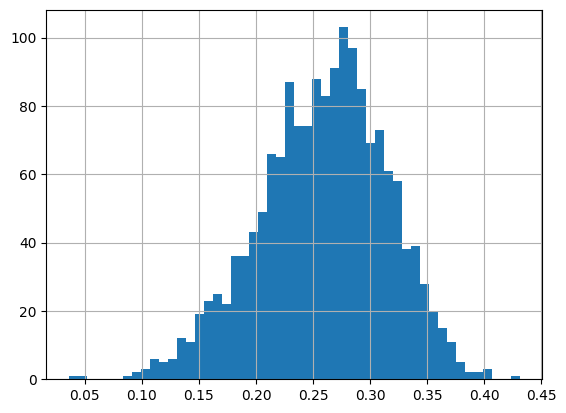

In [23]:
# Function to safely parse and process the grounding list
def process_grounding_biomedclip(row):
    try:
        grounding_biomedclip = ast.literal_eval(row['grounding_biomedclip_processed'])
        grounding_biomedclip = [x / 100 for x in grounding_biomedclip]  # Min-max scaling with max=100
        return sum(grounding_biomedclip) / len(grounding_biomedclip) if grounding_biomedclip else 0
    except (ValueError, SyntaxError, TypeError):
        return None  # Return None to drop later

# Drop rows with missing or invalid data first
df = df.dropna(subset=['grounding_biomedclip_processed'])

# Apply the processing function
df['grounding_biomedclip_mean_min_max_scaled'] = df.apply(process_grounding_biomedclip, axis=1)

# Drop rows that resulted in None (invalid parsing)
df = df.dropna(subset=['grounding_biomedclip_mean_min_max_scaled'])

# Summary statistics and histogram
print(df['grounding_biomedclip_mean_min_max_scaled'].describe())
df['grounding_biomedclip_mean_min_max_scaled'].hist(bins=50)